In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
df=pd.read_csv("tweets.csv",encoding="latin-1")
df

,Target,ID,Date,flag,User,Text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
1048570,4,1960186342,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Madelinedugganx,My GrandMa is making Dinenr with my Mum
1048571,4,1960186409,Fri May 29 07:33:43 PDT 2009,NO_QUERY,OffRoad_Dude,Mid-morning snack time... A bowl of cheese noo...
1048572,4,1960186429,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Falchion,@ShaDeLa same here say it like from the Termi...
1048573,4,1960186445,Fri May 29 07:33:44 PDT 2009,NO_QUERY,jonasobsessedx,@DestinyHope92 im great thaanks wbuu?


In [ ]:
df.shape

(1048575, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   Target  1048575 non-null  int64 
 1   ID      1048575 non-null  int64 
 2   Date    1048575 non-null  object
 3   flag    1048575 non-null  object
 4   User    1048575 non-null  object
 5   Text    1048575 non-null  object
dtypes: int64(2), object(4)
memory usage: 48.0+ MB


In [ ]:
df.isna().sum()

,0
Target,0
ID,0
Date,0
flag,0
User,0
Text,0


In [ ]:
df["Target"].unique()

array([0, 4])

In [ ]:
df["Target"]=df["Target"].replace({4:1})
df["Target"].unique()

array([0, 1])

In [ ]:
df["Target"].value_counts()

,count
Target,
0,799999
1,248576


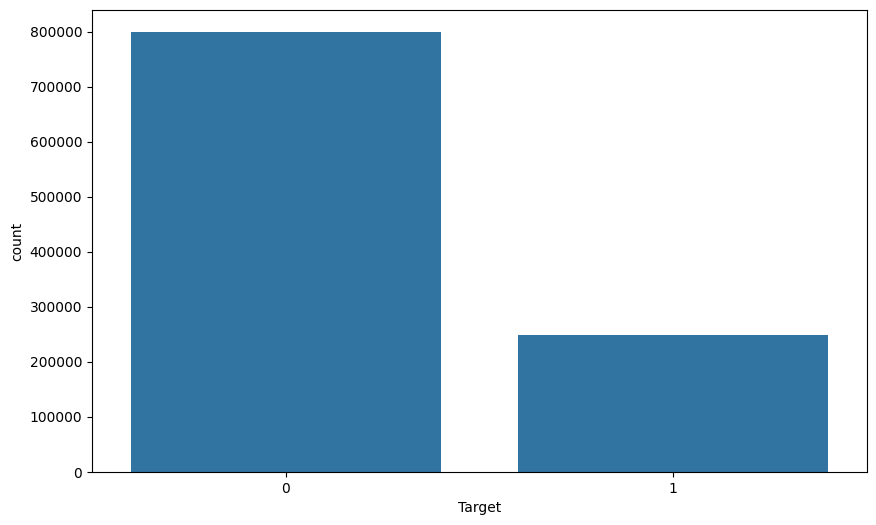

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x="Target"
)
plt.show()

In [ ]:
df_neg=df[df["Target"]==0].sample(n=260000,random_state=22)
df_pos=df[df["Target"]==1]
print(df_neg.shape)
print(df_pos.shape)

(260000, 6)
(248576, 6)


In [ ]:
df_balanced=pd.concat([df_neg,df_pos],ignore_index=True)
df_balanced.shape

(508576, 6)

In [ ]:
df_balanced.head()

,Target,ID,Date,flag,User,Text
0,0,2251786900,Sat Jun 20 04:34:41 PDT 2009,NO_QUERY,Luiza_Pantoja,"@mcflymusic I wish I was!! c'mon, no Brazilian..."
1,0,2043957759,Fri Jun 05 08:39:48 PDT 2009,NO_QUERY,Disney_Dreaming,@MCTroy Zac doesn't have a twitter which is s...
2,0,1824488835,Sun May 17 01:36:05 PDT 2009,NO_QUERY,widyatarina,i pulled my muscles they're killing me..haha
3,0,2243606702,Fri Jun 19 13:39:59 PDT 2009,NO_QUERY,rocky91,Almost time to for the party! but it's gloomy ...
4,0,1985094007,Sun May 31 16:25:06 PDT 2009,NO_QUERY,MichelleTiffany,Home...My car is dead Step dad lent me the va...


In [ ]:
df_balanced.tail()

,Target,ID,Date,flag,User,Text
508571,1,1960186342,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Madelinedugganx,My GrandMa is making Dinenr with my Mum
508572,1,1960186409,Fri May 29 07:33:43 PDT 2009,NO_QUERY,OffRoad_Dude,Mid-morning snack time... A bowl of cheese noo...
508573,1,1960186429,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Falchion,@ShaDeLa same here say it like from the Termi...
508574,1,1960186445,Fri May 29 07:33:44 PDT 2009,NO_QUERY,jonasobsessedx,@DestinyHope92 im great thaanks wbuu?
508575,1,1960186607,Fri May 29 07:33:45 PDT 2009,NO_QUERY,sugababez,cant wait til her date this weekend


In [ ]:
df_balanced=df_balanced.sample(frac=1,random_state=22).reset_index(drop=True)

In [ ]:
df_balanced.head()

,Target,ID,Date,flag,User,Text
0,0,1974439532,Sat May 30 13:08:22 PDT 2009,NO_QUERY,alexcarlson,Florida!!!!!!!!!!!!!! Just got back from the b...
1,1,1792537659,Wed May 13 23:26:20 PDT 2009,NO_QUERY,_spell,@MistySunrise 'enunciates' was the correct spe...
2,1,1557961698,Sun Apr 19 06:44:41 PDT 2009,NO_QUERY,jenipferd,I had a long weekend !!!
3,0,1469931533,Tue Apr 07 07:50:53 PDT 2009,NO_QUERY,charlinejonas,miley and demi please reply
4,0,2188467058,Mon Jun 15 21:57:13 PDT 2009,NO_QUERY,lizmathews12,@WVUfootball haha! Owen Schmitt the rockstar!...


In [ ]:
df_balanced.tail()

,Target,ID,Date,flag,User,Text
508571,0,2202315916,Tue Jun 16 21:35:25 PDT 2009,NO_QUERY,tat_zizzy,tweetdeck for iphone keeps crashing!
508572,0,1834509642,Mon May 18 03:12:27 PDT 2009,NO_QUERY,joanneferrer,@BostonCeltics1 Too bad for the C's
508573,1,1932590746,Tue May 26 21:47:02 PDT 2009,NO_QUERY,Jthemotorider,@rachelreadsalot mmmmm
508574,0,1573634915,Tue Apr 21 02:06:29 PDT 2009,NO_QUERY,_pebble_,@ItsKeat TT.TT its too late.... sorry :'( :'(
508575,1,1751988017,Sat May 09 20:46:24 PDT 2009,NO_QUERY,devyra,@PANICitsLeslie Aww that's still awesome. You ...


In [ ]:
df_balanced["Target"].value_counts()

,count
Target,
0,260000
1,248576


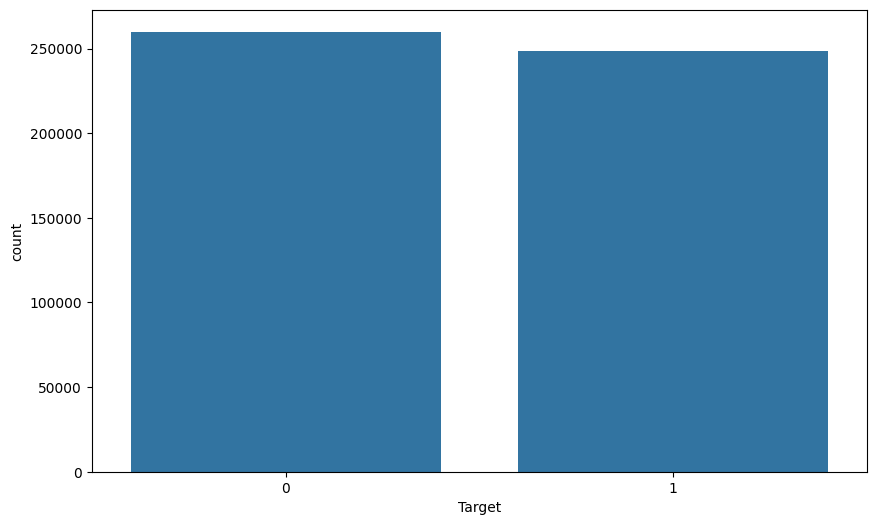

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df_balanced,
    x="Target"
)
plt.show()

In [ ]:
df_balanced.columns

Index(['Target', 'ID', 'Date', 'flag', 'User', 'Text'], dtype='object')

In [ ]:
main_df=df_balanced.drop(["ID","Date","flag","User"],axis=1)
main_df

,Target,Text
0,0,Florida!!!!!!!!!!!!!! Just got back from the b...
1,1,@MistySunrise 'enunciates' was the correct spe...
2,1,I had a long weekend !!!
3,0,miley and demi please reply
4,0,@WVUfootball haha! Owen Schmitt the rockstar!...
...,...,...
508571,0,tweetdeck for iphone keeps crashing!
508572,0,@BostonCeltics1 Too bad for the C's
508573,1,@rachelreadsalot mmmmm
508574,0,@ItsKeat TT.TT its too late.... sorry :'( :'(


In [ ]:
def cleaning(sentence):
    text = sentence.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
main_df["Text"]=main_df["Text"].apply(cleaning)
main_df["Text"][:10]

,Text
0,florida just got back from the beach and im no...
1,mistysunrise enunciates was the correct spelli...
2,i had a long weekend
3,miley and demi please reply
4,wvufootball haha owen schmitt the rockstar tha...
5,ellyhart good morningevening elly i would love...
6,wants carolina dean to know that the death of ...
7,morning escuchando el soundtrack de twilight q...
8,vixstar oh noooo the baby or ur mini me i miss...
9,emoprincemartin how come message me on bebo x


In [ ]:
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

lem=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))

def wordnet_pos(tag):
  if tag.startswith("N"):
    return 'n'
  elif tag.startswith("V"):
    return 'v'
  elif tag.startswith("J"):
    return 'a'
  elif tag.startswith("R"):
    return 'r'
  else:
    return 'n'

def preprocessing(sentence):
  words=sentence.split()
  words=[word for word in words if word not in stop_words]
  words_tag=pos_tag(words)
  words=[lem.lemmatize(word,pos=wordnet_pos(tag)) for word,tag in words_tag]
  return " ".join(words)

In [ ]:
main_df["Text"]=main_df["Text"].apply(preprocessing)
main_df["Text"][:11]

,Text
0,florida get back beach im lounge around houses...
1,mistysunrise enunciates correct spell always t...
2,long weekend
3,miley demi please reply
4,wvufootball haha owen schmitt rockstar thanks ...
5,ellyhart good morningevening elly would love s...
6,want carolina dean know death friendship one s...
7,morning escuchando el soundtrack de twilight q...
8,vixstar oh noooo baby ur mini miss u soooo wha...
9,emoprincemartin come message bebo x


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.8
)
X=vectorizer.fit_transform(main_df["Text"])
print(X)
print(X[0].toarray())
print(vectorizer.get_feature_names_out()[:20])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3678059 stored elements and shape (508576, 10000)>
  Coords	Values
  (0, 2652)	0.3132644149880346
  (0, 2876)	0.12172064831994611
  (0, 475)	0.1604502669632413
  (0, 600)	0.24786472336603688
  (0, 4152)	0.12018705020406317
  (0, 5224)	0.32937947718274146
  (0, 339)	0.22617673380143988
  (0, 7251)	0.1841170728186572
  (0, 8807)	0.18038182074684433
  (0, 4796)	0.17595834203330846
  (0, 2796)	0.2481398091749367
  (0, 1643)	0.1370238879226521
  (0, 2882)	0.24689560324295565
  (0, 8818)	0.36782460869394074
  (0, 4803)	0.3684308693717762
  (0, 2797)	0.3406405217543612
  (1, 1442)	0.48512198218096053
  (1, 7890)	0.44380400035405954
  (1, 171)	0.312092979615225
  (1, 8522)	0.23686972472309684
  (1, 9828)	0.3556626817406828
  (1, 184)	0.5363668838361205
  (2, 5143)	0.4844118461528689
  (2, 9446)	0.47362859033714894
  (2, 5158)	0.735541380020196
  :	:
  (508570, 1213)	0.3349031932048578
  (508570, 9352)	0.2650447128676588
  (508570, 9

In [ ]:
y=main_df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=22
)
print(X_train.shape)
print(X_test.shape)

(406860, 10000)
(101716, 10000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train,y_train)
y_pred_nb=model.predict(X_test)
y_pred_nb

array([1, 0, 0, ..., 1, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

print(f'Accuracy Score by multinomialNB model : {accuracy_score(y_test, y_pred_nb)}')
print(f'Recall Score multinomialNB model : {recall_score(y_test, y_pred_nb)}')
print(f'Precision Score multinomialNB model : {precision_score(y_test, y_pred_nb)}')
print(f'F1 Score multinomialNB model : {f1_score(y_test, y_pred_nb)}')

print("Classification Report multinomialNB model :\n", classification_report(y_test, y_pred_nb))

Accuracy Score by multinomialNB model : 0.7644126784380039
Recall Score multinomialNB model : 0.7413447318842048
Precision Score multinomialNB model : 0.7657459719606612
F1 Score multinomialNB model : 0.7533478122137247
Classification Report multinomialNB model :
               precision    recall  f1-score   support

           0       0.76      0.79      0.77     52353
           1       0.77      0.74      0.75     49363

    accuracy                           0.76    101716
   macro avg       0.76      0.76      0.76    101716
weighted avg       0.76      0.76      0.76    101716



In [ ]:
cm1=confusion_matrix(y_test,y_pred_nb)
print(f'Confusion matrix by multinomialNB model:\n {cm1}')

Confusion matrix by multinomialNB model:
 [[41158 11195]
 [12768 36595]]


<Axes: >

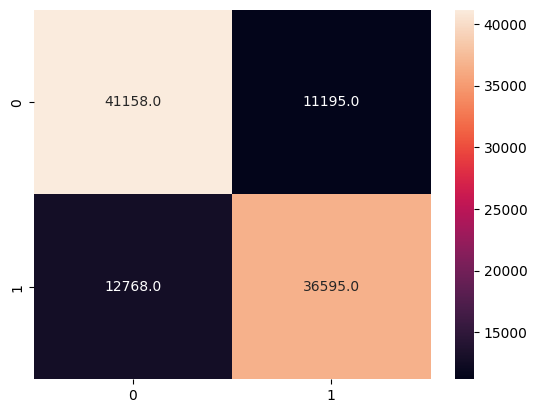

In [ ]:
sns.heatmap(
    confusion_matrix(y_test,y_pred_nb),
    annot=True,
    fmt=".1f")

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
y_pred_lr=lr_model.predict(X_test)
y_pred_lr

array([1, 1, 0, ..., 1, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

print(f'Accuracy Score by logestic regression model : {accuracy_score(y_test, y_pred_lr)}')
print(f'Recall Score by logestic regression model : {recall_score(y_test, y_pred_lr)}')
print(f'Precision Score by logestic regression model : {precision_score(y_test, y_pred_lr)}')
print(f'F1 Score by logestic regression model : {f1_score(y_test, y_pred_lr)}')

print("Classification Report by logestic regression model :\n", classification_report(y_test, y_pred_lr))

Accuracy Score by logestic regression model : 0.7801034252231704
Recall Score by logestic regression model : 0.7892348520146668
Precision Score by logestic regression model : 0.7650720710105652
F1 Score by logestic regression model : 0.7769656479034751
Classification Report by logestic regression model :
               precision    recall  f1-score   support

           0       0.80      0.77      0.78     52353
           1       0.77      0.79      0.78     49363

    accuracy                           0.78    101716
   macro avg       0.78      0.78      0.78    101716
weighted avg       0.78      0.78      0.78    101716



In [ ]:
cm2=confusion_matrix(y_test,y_pred_lr)
print(f'Confusion matrix by logestic regression model:\n {cm2}')

Confusion matrix by logestic regression model:
 [[40390 11963]
 [10404 38959]]


<Axes: >

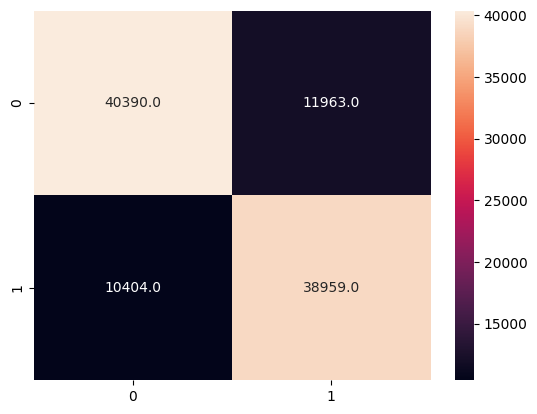

In [ ]:
sns.heatmap(
    cm2,
    annot=True,
    fmt=".1f"
)

In [ ]:
import joblib

joblib.dump(lr_model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']